# TT — Capa geométrica y evacuación

**Alcance de este notebook.** Solo la capa geométrica (restricciones duras) y la primera
función objetivo (tiempo de evacuación). Todavía **no** hay NSGA-II: el plan acordado es
averiguar primero si el problema es genuinamente multiobjetivo, barriendo pesos sobre una
suma ponderada, antes de montar un algoritmo multiobjetivo.

**Regla de trabajo:** ningún coeficiente se inventa. Cada parámetro declara su procedencia
y los que no tienen fuente verificada se marcan como `PENDIENTE` y bloquean la tesis.

**El flujo:**

```
  layout propuesto
        ↓
  CAPA GEOMÉTRICA  ── ilegal ──▶ descartado sin simular
        ↓ legal
  FMM desde salidas (recinto vacío) → área útil → aforo
        ↓
  campo Eikonal + isócronas
        ↓
  Weidmann + Godunov → evacuación → t95
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'nucleo')))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import parametros as P
import recinto as R
import geometria as G
import campos as C
import fluido as F
import viz as V

plt.rcParams['figure.facecolor'] = V.FONDO
plt.rcParams['axes.facecolor']   = '#0f131a'
plt.rcParams['text.color']       = V.TINTA
plt.rcParams['axes.labelcolor']  = V.TINTA
plt.rcParams['xtick.color']      = V.TENUE
plt.rcParams['ytick.color']      = V.TENUE
print('listo')

listo


## 1. Parámetros y su procedencia

Esta tabla es el control de calidad del modelo. Los estados significan:

| estado | qué implica |
|---|---|
| `medido` | valor empírico publicado → **se cita** |
| `derivado` | se calcula de otros → no requiere cita propia |
| `normativo` | lo fija un reglamento → se cita artículo |
| `catalogo` | dimensión de equipo comercial → se cita proveedor |
| `numerico` | discretización → requiere **estudio de convergencia** |
| `calibrar` | modelado, sin contraparte empírica directa → requiere **análisis de sensibilidad** |
| `PENDIENTE` | no se ha verificado la fuente → **bloquea la tesis** |

In [2]:
df = pd.DataFrame(P.tabla(), columns=['clave','símbolo','valor','unidad','estado','fuente','nota'])
print('PARÁMETROS PENDIENTES DE FUENTE (hay que resolverlos):')
for k in P.pendientes():
    p = P.REGISTRO[k]
    print('   %-22s %-8s %-14s  <- %s' % (k, p.valor, p.unidad, p.fuente))
print()
df[['clave','símbolo','valor','unidad','estado','fuente']]

PARÁMETROS PENDIENTES DE FUENTE (hay que resolverlos):
   J_ESPECIFICO           1.32     pers/(s·m)      <- Seyfried et al., experimentos de cuello de botella (grupo de Juelich)
   CAPA_LIMITE            0.15     m               <- Seyfried et al.; efecto de borde en cuellos de botella
   ANCHO_LIBRE_MIN        3.0      m               <- Reglamento de Construcciones CDMX + NTC para el Proyecto Arquitectonico
   DIST_MAX_SALIDA        40.0     m               <- RCDF + NTC / reglamento contra incendios aplicable
   T_EVAC_MAX             600.0    s               <- Programa Especial de Proteccion Civil / criterio del proyecto
   PROF_DESPEJE_SALIDA    1.5      × ancho         <- RCDF/NTC: area de descarga de salidas



,clave,símbolo,valor,unidad,estado,fuente
0,ANCHO_LIBRE_MIN,w_min,3.000000,m,PENDIENTE,Reglamento de Construcciones CDMX + NTC para e...
1,CAPA_LIMITE,b,0.150000,m,PENDIENTE,Seyfried et al.; efecto de borde en cuellos de...
2,DIST_MAX_SALIDA,d_max,40.000000,m,PENDIENTE,RCDF + NTC / reglamento contra incendios aplic...
3,J_ESPECIFICO,J_s,1.320000,pers/(s·m),PENDIENTE,"Seyfried et al., experimentos de cuello de bot..."
4,PROF_DESPEJE_SALIDA,d_s,1.500000,× ancho,PENDIENTE,RCDF/NTC: area de descarga de salidas
5,T_EVAC_MAX,t_max,600.000000,s,PENDIENTE,Programa Especial de Proteccion Civil / criter...
6,FRACCION_PERDIDA_MAX,φ_max,0.030000,-,calibrar,Criterio de diseno del proyecto (NO es una con...
7,RHO_DISENO,ρ_d,3.500000,pers/m²,calibrar,Acotado por RHO_PERDIDA_CONTROL como techo fisico
8,SIGMA_KERNEL,σ_k,2.000000,celdas,calibrar,"Treuille, Cooper & Popovic (2006), Continuum C..."
9,DT,Δt,0.400000,s,numerico,-


In [3]:
# la nota completa de cualquier parámetro
for k in ('RHO_PERDIDA_CONTROL', 'SIGMA_KERNEL', 'RHO_DISENO'):
    p = P.REGISTRO[k]
    print('%s  (%s = %s %s)' % (k, p.simbolo, p.valor, p.unidad))
    print('   fuente:', p.fuente)
    print('   nota  :', p.nota.replace('\n', '\n           '))
    print()

RHO_PERDIDA_CONTROL  (ρ_c = 4.0 pers/m²)
   fuente: van Toll et al., SPH-enhanced crowd simulation, Computers & Graphics (2021); INRIA hal-03270915
   nota  : Por encima de este valor la gente PIERDE el movimiento individual y es desplazada por la presion del grupo. Es el mejor argumento para usar un modelo continuo: arriba de aqui, la decision individual que simulan los modelos de agentes es justamente lo que deja de ocurrir.

SIGMA_KERNEL  (σ_k = 2.0 celdas)
   fuente: Treuille, Cooper & Popovic (2006), Continuum Crowds, ACM TOG 25(3)
   nota  : Ancho del nucleo con que se estima la densidad continua a partir de la masa discreta. En Continuum Crowds la densidad se obtiene por splatting con nucleo; en SPH es el smoothing kernel. NO es un filtro cosmetico: es parte del estimador de densidad, y por eso entra en el modelo. Requiere analisis de sensibilidad.

RHO_DISENO  (ρ_d = 3.5 pers/m²)
   fuente: Acotado por RHO_PERDIDA_CONTROL como techo fisico
   nota  : Densidad de diseno para cal

## 2. El recinto y el catálogo de áreas

**Decisión de representación: colocación directa**, no *Flexible Bay Structure*.

FBS es la representación estándar del UA-FLP (Tong 1991; Tate & Smith 1995) y particiona todo
el recinto en bandas. No sirve aquí por dos razones propias de este problema:

1. El usuario **pinta muros y elementos fijos**. FBS no admite clavar un obstáculo
   preexistente en medio de una banda.
2. Aquí se colocan pocas áreas chicas en un espacio mayormente vacío. Eso es un problema de
   **colocación**, no de **partición**.

El costo: los traslapes dejan de ser imposibles por construcción y hay que verificarlos. Con
áreas chicas en espacio amplio sale barato.

In [4]:
rec = R.recinto_ejemplo(h=1.0)
print('recinto %.0f × %.0f m,  celda %.2f m  (%d × %d)' % (rec.W, rec.H, rec.h, rec.nx, rec.ny))
print('salidas:')
for s in rec.salidas:
    print('   %-4s lado %s  centro %5.1f m  ancho %.1f m  ->  ancho útil %.2f m'
          % (s.nombre, s.lado, s.centro, s.ancho, s.ancho_util(P.CAPA_LIMITE)))
print('ancho útil TOTAL: %.1f m' % rec.ancho_total_salidas(P.CAPA_LIMITE))
print()
print('catálogo de áreas de servicio:')
for t in R.CATALOGO:
    print('   %-4s %-20s %.1f × %.1f m = %5.1f m²' % (t.clave, t.nombre, t.ancho, t.fondo, t.area))

recinto 100 × 60 m,  celda 1.00 m  (100 × 60)
salidas:
   S1   lado S  centro  20.0 m  ancho 8.0 m  ->  ancho útil 7.70 m
   S2   lado S  centro  70.0 m  ancho 8.0 m  ->  ancho útil 7.70 m
   O1   lado O  centro  30.0 m  ancho 6.0 m  ->  ancho útil 5.70 m
   E1   lado E  centro  35.0 m  ancho 6.0 m  ->  ancho útil 5.70 m
ancho útil TOTAL: 26.8 m

catálogo de áreas de servicio:
   SAN  Modulo sanitario     8.0 × 3.0 m =  24.0 m²
   COM  Carpa de comida      5.0 × 5.0 m =  25.0 m²
   BEB  Barra de bebidas     8.0 × 2.5 m =  20.0 m²
   MED  Primeros auxilios    5.0 × 5.0 m =  25.0 m²


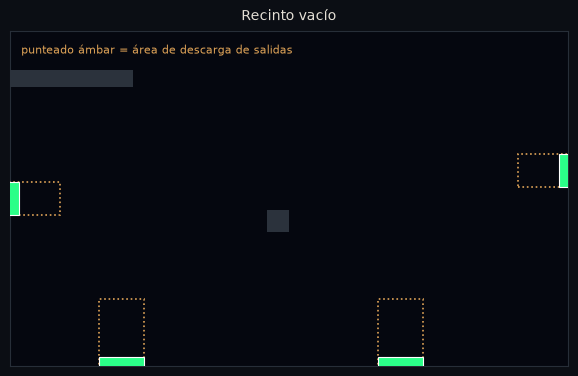

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
V.dibujar_muros(ax, rec); V.dibujar_salidas(ax, rec); V.estilo(ax, rec, 'Recinto vacío')
for nom, cono in G.conos_salida(rec):
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle(cono[:2], cono[2], cono[3], fill=False, ec='#e0a458',
                           ls=':', lw=1.2, zorder=4))
ax.text(0.02, 0.96, 'punteado ámbar = área de descarga de salidas', transform=ax.transAxes,
        color='#e0a458', fontsize=8, va='top')
plt.show()

## 3. Capa geométrica — la restricción dura

Se ejecuta **antes** de cualquier simulación. Si no cabe un baño, no tiene sentido preguntarse
cuánto tarda la evacuación.

| chequeo | qué evita |
|---|---|
| **G1** dentro del recinto | áreas fuera de los límites |
| **G2** sin traslape | dos áreas en el mismo lugar |
| **G3** sin invadir muros | áreas encima de elementos de obra |
| **G4** salidas despejadas | tapar una puerta o su área de descarga |
| **G5** área útil conservada | amurallar zonas o dejar pasillos angostos |

**G5 merece explicación.** Se erosiona el piso libre por medio ancho normativo: lo que
sobrevive es la red por la que **sí** se puede circular legalmente. Se conserva la parte
conectada a alguna salida y se dilata de vuelta.

Un recoveco detrás de un puesto, al que no se entra con el ancho de reglamento, **no es una
violación de seguridad: es superficie que no se puede usar**. Por eso sale de la zona ocupable
en vez de contar como infracción. (Al formularlo mal al principio, el 87 % de las colocaciones
se rechazaban por huecos de 18 m² que no atrapaban a nadie.)

In [6]:
rng = np.random.default_rng(3)
malo = R.layout_aleatorio(rec, rng)          # sin reparar: casi seguro ilegal
res  = G.evaluar(rec, malo, corto=False)     # corto=False para ver TODOS los fallos

print('violación total: %.1f   factible: %s' % (res['violacion'], res['factible']))
for p in res['pasos']:
    marca = 'x' if p['violacion'] > 0 else 'ok'
    print('  [%-2s] %-32s %8.2f' % (marca, p['nombre'], p['violacion']))

violación total: 25.1   factible: False
  [ok] G1 dentro del recinto                0.00
  [ok] G2 sin traslape entre areas          0.00
  [x ] G3 sin invadir muros fijos           4.00
  [x ] G4 salidas despejadas               21.08
  [ok] G5 area util conservada              0.00


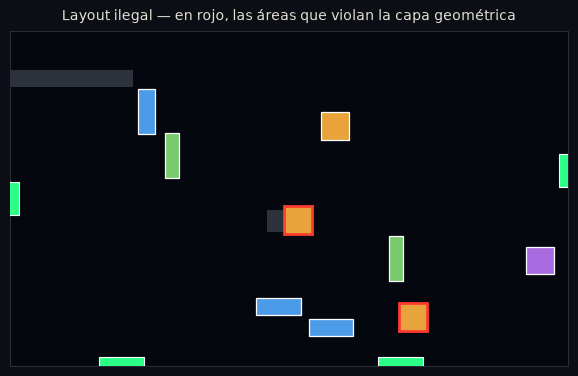

In [7]:
# ¿QUIÉN falla? el detalle trae los índices culpables
fig, ax = plt.subplots(figsize=(7.2, 4.6))
culpables = set()
for p in res['pasos']:
    culpables |= set(p['detalle'].get('culpables', []))
    for a, b in p['detalle'].get('pares', []):
        culpables |= {a, b}
V.dibujar_muros(ax, rec)
V.dibujar_layout(ax, rec, malo, resaltar=culpables)
V.dibujar_salidas(ax, rec)
V.estilo(ax, rec, 'Layout ilegal — en rojo, las áreas que violan la capa geométrica')
plt.show()

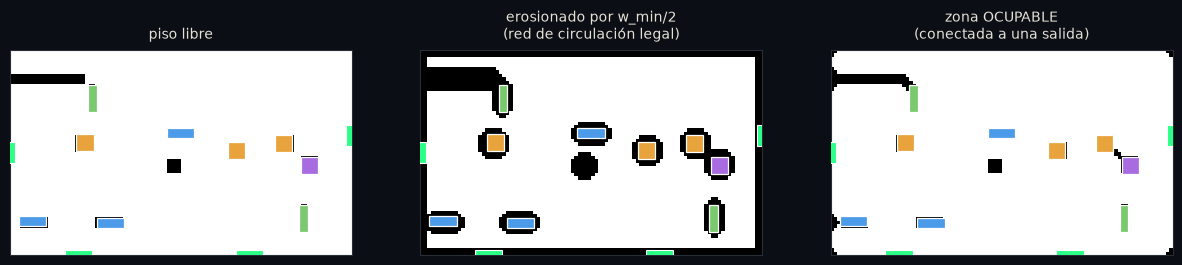

área libre      5714 m²
área ocupable   5677 m²


In [8]:
# la zona ocupable: qué piso queda realmente utilizable
bueno = R.layout_factible(rec, np.random.default_rng(11))
oc, det = G.zona_ocupable(rec, bueno)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (m, t) in zip(axes, [(rec.libre(bueno), 'piso libre'),
                             (det['erosion'], 'erosionado por w_min/2\n(red de circulación legal)'),
                             (oc, 'zona OCUPABLE\n(conectada a una salida)')]):
    ax.imshow(m, origin='lower', extent=[0, rec.W, 0, rec.H], cmap='bone', zorder=1)
    V.dibujar_layout(ax, rec, bueno); V.dibujar_salidas(ax, rec); V.estilo(ax, rec, t)
plt.show()

print('área libre    %6.0f m²' % (rec.libre(bueno).sum() * rec.area_celda))
print('área ocupable %6.0f m²' % (oc.sum() * rec.area_celda))

## 4. FMM sobre el recinto vacío → área útil e isócronas → aforo

La **ecuación Eikonal**:

$$|\nabla T(\mathbf{x})| = \frac{1}{v(\mathbf{x})}, \qquad T = 0 \ \text{en las salidas}$$

En palabras: *el tiempo de llegada crece a razón de uno sobre la velocidad local*. Donde la
gente va lento, el tiempo se acumula rápido.

Se resuelve con **Fast Marching Method** (Sethian 1996): un frente que avanza desde las
salidas hacia adentro, más lento donde hay congestión. Las celdas a las que el frente **nunca
llega** quedan con $T=\infty$: son zonas sin ruta a ninguna salida.

Y la dirección de movimiento sale gratis: la gente camina hacia donde $T$ baja más rápido,
o sea $-\nabla T$.

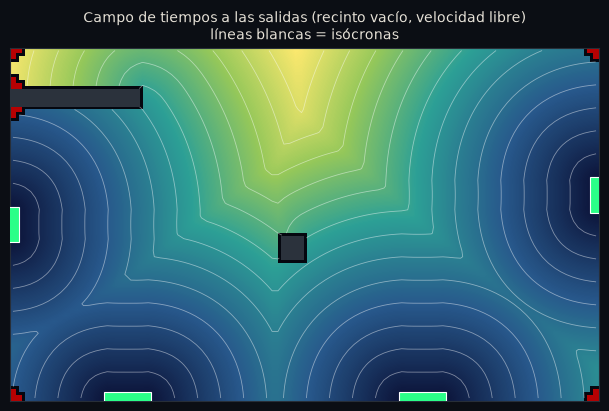

tiempo máximo a una salida: 41 s  (= 55 m a velocidad libre)
área total        6000 m²
área ocupable     5900 m²
área aislada         0 m²   <- sin ruta a ninguna salida


In [9]:
d = C.diagnostico_area(rec)          # sin áreas de servicio: solo el recinto y sus muros
T0 = d['T']

fig, ax = plt.subplots(figsize=(7.6, 4.8))
vmax = V.mapa_tiempos(ax, rec, T0, None, isocronas=True, n_iso=14)
ax.set_title('Campo de tiempos a las salidas (recinto vacío, velocidad libre)\n'
             'líneas blancas = isócronas', fontsize=10, color=V.TINTA)
plt.show()

print('tiempo máximo a una salida: %.0f s  (= %.0f m a velocidad libre)' % (vmax, vmax * P.V0))
print('área total      %6.0f m²' % d['area_total'])
print('área ocupable   %6.0f m²' % d['area_alcanzable'])
print('área aislada    %6.0f m²   <- sin ruta a ninguna salida' % d['area_aislada'])

In [10]:
CONTEO = {'SAN': 3, 'COM': 3, 'BEB': 2, 'MED': 1}
est = C.estimar_aforo(rec, CONTEO)

print('AFORO')
print('  área con ruta a salida        %8.0f m²' % est['area_alcanzable'])
print('  − área que ocuparán servicios %8.0f m²' % est['area_servicios'])
print('  = área neta                   %8.0f m²' % est['area_neta'])
print('  × densidad de diseño          %8.2f pers/m²   (ρ_d, parámetro a justificar)' % P.RHO_DISENO)
print('  ------------------------------------------')
print('  AFORO                         %8.0f personas' % est['aforo'])
print()
Wu = rec.ancho_total_salidas(P.CAPA_LIMITE)
print('cota inferior por capacidad de salidas:')
print('  aforo / (J_s · ancho útil) = %.0f / (%.2f · %.1f) = %.0f s'
      % (est['aforo'], P.J_ESPECIFICO, Wu, est['aforo'] / (P.J_ESPECIFICO * Wu)))

AFORO
  área con ruta a salida            5900 m²
  − área que ocuparán servicios      212 m²
  = área neta                       5688 m²
  × densidad de diseño              3.50 pers/m²   (ρ_d, parámetro a justificar)
  ------------------------------------------
  AFORO                            19908 personas

cota inferior por capacidad de salidas:
  aforo / (J_s · ancho útil) = 19908 / (1.32 · 26.8) = 563 s


## 5. El layout deforma el campo

Mismo cálculo, ahora con las áreas de servicio como obstáculos. Compara las isócronas: donde
se aprietan, el layout está estorbando.

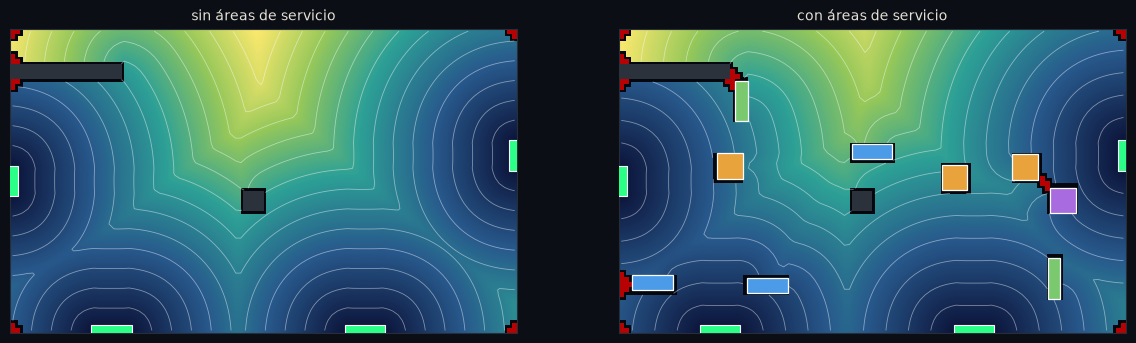

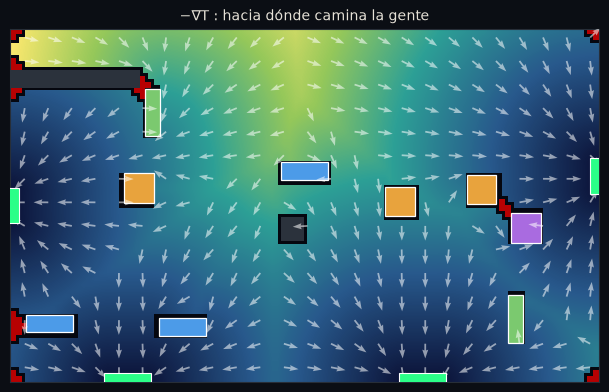

In [11]:
oc_b, _ = G.zona_ocupable(rec, bueno)
T1 = C.campo_tiempos(rec, oc_b, rec.mascara_salidas())

fig, axes = plt.subplots(1, 2, figsize=(14.4, 4.5))
V.mapa_tiempos(axes[0], rec, T0, None, n_iso=14)
axes[0].set_title('sin áreas de servicio', fontsize=10, color=V.TINTA)
V.mapa_tiempos(axes[1], rec, T1, bueno, n_iso=14)
axes[1].set_title('con áreas de servicio', fontsize=10, color=V.TINTA)
plt.show()

ux, uy = C.direccion(T1, oc_b, rec.h)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
V.mapa_tiempos(ax, rec, T1, bueno, isocronas=False)
V.flechas(ax, rec, ux, uy, oc_b, paso=4, alpha=0.55)
ax.set_title('−∇T : hacia dónde camina la gente', fontsize=10, color=V.TINTA)
plt.show()

## 6. Diagrama fundamental de Weidmann

La **única física empírica** del modelo. Relaciona densidad con velocidad:

$$v(\rho) = v_0 \left[ 1 - \exp\left(-\gamma\left(\frac{1}{\rho} - \frac{1}{\rho_{max}}\right)\right)\right]$$

Sin esto el modelo predeciría que las multitudes **aceleran** en los cuellos de botella, que es
lo contrario de la realidad.

De ahí sale el flujo $q(\rho) = \rho\,v(\rho)$, que tiene un **máximo**: la capacidad.
**Ese máximo no se pone a mano, se deriva** — y sirve como primera prueba de validación contra
los experimentos de cuello de botella publicados.

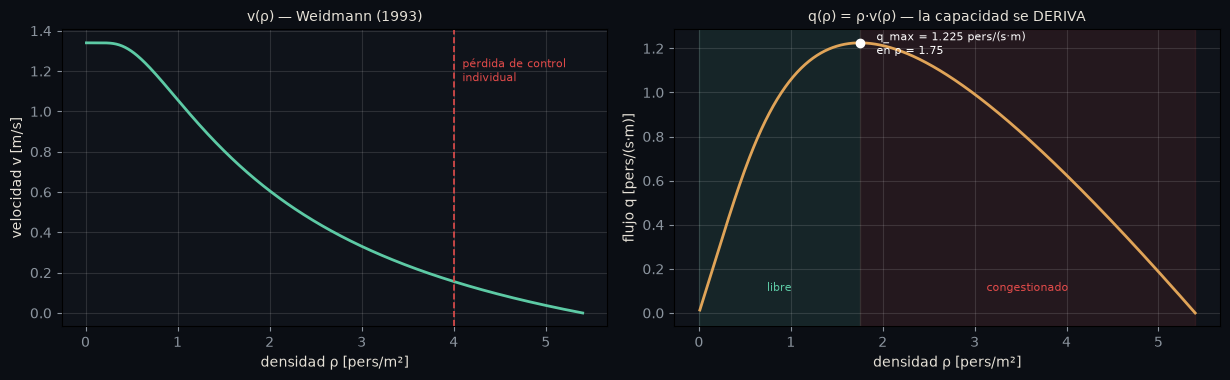

In [12]:
r = np.linspace(0.01, P.RHO_MAX, 500)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.9))

axes[0].plot(r, F.weidmann(r), color='#5dcaa5', lw=2)
axes[0].axvline(P.RHO_PERDIDA_CONTROL, color='#e24b4a', ls='--', lw=1.2)
axes[0].text(P.RHO_PERDIDA_CONTROL + .05, 1.15, ' pérdida de control\n individual',
             color='#e24b4a', fontsize=8)
axes[0].set_xlabel('densidad ρ [pers/m²]'); axes[0].set_ylabel('velocidad v [m/s]')
axes[0].set_title('v(ρ) — Weidmann (1993)', fontsize=10)

axes[1].plot(r, F.flujo(r), color='#e0a458', lw=2)
axes[1].plot([F.RHO_CAP], [F.Q_MAX], 'o', color='white', ms=6)
axes[1].annotate('q_max = %.3f pers/(s·m)\nen ρ = %.2f' % (F.Q_MAX, F.RHO_CAP),
                 (F.RHO_CAP, F.Q_MAX), textcoords='offset points', xytext=(12, -8),
                 color='white', fontsize=8)
axes[1].axvspan(0, F.RHO_CAP, alpha=.10, color='#5dcaa5')
axes[1].axvspan(F.RHO_CAP, P.RHO_MAX, alpha=.10, color='#e24b4a')
axes[1].text(F.RHO_CAP/2, .1, 'libre', ha='center', color='#5dcaa5', fontsize=8)
axes[1].text((F.RHO_CAP+P.RHO_MAX)/2, .1, 'congestionado', ha='center', color='#e24b4a', fontsize=8)
axes[1].set_xlabel('densidad ρ [pers/m²]'); axes[1].set_ylabel('flujo q [pers/(s·m)]')
axes[1].set_title('q(ρ) = ρ·v(ρ) — la capacidad se DERIVA', fontsize=10)
for a in axes: a.grid(alpha=.12, color='white')
plt.tight_layout(); plt.show()

> **Primera prueba de validación.** La capacidad derivada debe caer dentro del rango medido en
> experimentos de cuello de botella con peatones. Si no cae, el modelo está mal calibrado
> **antes** de simular nada. Contrastar contra Seyfried et al. (grupo de Jülich) y anotar el
> valor exacto con su experimento.

## 7. Conservación de masa + esquema de Godunov

La gente se transporta resolviendo la ley de conservación **LWR** (Lighthill & Whitham 1955;
Richards 1956) con el esquema de Godunov en su forma de **modelo de transmisión de celdas**
(Daganzo 1994).

La regla que lo hace funcionar:

> una celda no puede **enviar** más de lo que su densidad permite,
> y sobre todo **no puede recibir más de lo que le cabe**.

Sin la segunda condición la masa se apila sin límite, la densidad llega a $\rho_{max}$,
Weidmann la deja a velocidad cero y la celda **se congela para siempre**. Con ella aparecen
colas reales: la congestión se propaga hacia atrás, igual que en el tráfico.

Detalle fino pero decisivo: **una celda congestionada sigue queriendo descargar a capacidad.**
Lo que la frena es que la de adelante no la acepta. Si en la demanda se pusiera $\rho v(\rho)$
—que tiende a cero al congestionarse— las celdas llenas se congelarían y aparece un moteado de
tablero de ajedrez.

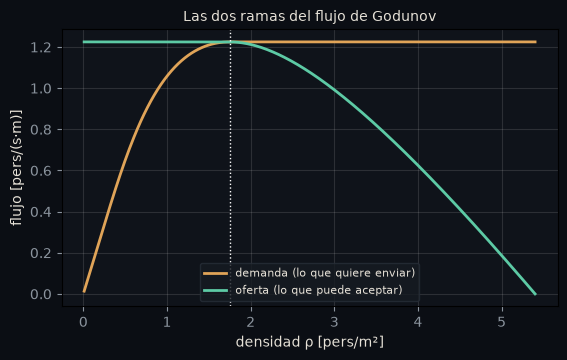

In [13]:
rr = np.linspace(0.01, P.RHO_MAX, 400)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(rr, F.demanda(rr), lw=2, color='#e0a458', label='demanda (lo que quiere enviar)')
ax.plot(rr, F.oferta(rr),  lw=2, color='#5dcaa5', label='oferta (lo que puede aceptar)')
ax.axvline(F.RHO_CAP, color='white', ls=':', lw=1)
ax.set_xlabel('densidad ρ [pers/m²]'); ax.set_ylabel('flujo [pers/(s·m)]')
ax.set_title('Las dos ramas del flujo de Godunov', fontsize=10)
ax.legend(fontsize=8, facecolor='#161b22', edgecolor='#272e38', labelcolor=V.TINTA)
ax.grid(alpha=.12, color='white'); plt.show()

## 8. La distribución inicial decide si el layout importa

**Este es el hallazgo más importante del notebook.**

El supuesto natural para el peor caso es *"aforo lleno repartido uniformemente"*. **Está mal**
— no es el peor caso, es **el que menos discrimina**: con todo el mundo repartido siempre hay
una salida cerca, las puertas saturan y el layout deja de importar.

Con la multitud **concentrada frente al escenario** —la situación real de un concierto— toda la
masa tiene que cruzar la misma región y el layout sí decide.

Medido con una barrera deliberada contra un layout disperso, mismo aforo:

| distribución inicial | barrera | disperso | diferencia |
|---|---|---|---|
| uniforme | 685 s | 686 s | **−0.1 %** |
| concentrada (25 m) | 717 s | 686 s | +4.6 % |
| concentrada (12 m) | 792 s | 693 s | **+14.3 %** |

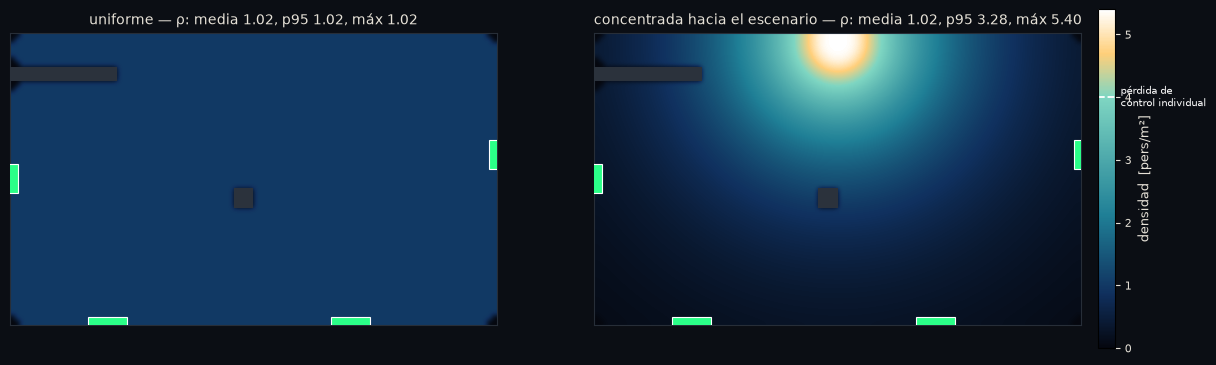

Nota: el perfil concentrado satura en ρ_max = 5.4. Lo que no cabe adelante
se recorre hacia atrás, que es lo que pasa de verdad.


In [14]:
AFORO, FOCO, ESCALA = 6000.0, (50.0, 58.0), 18.0
oc0, _ = G.zona_ocupable(rec, None)
M_uni = C.distribucion_inicial(rec, oc0, AFORO, foco=None)
M_con = C.distribucion_inicial(rec, oc0, AFORO, foco=FOCO, escala=ESCALA)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 4.4))
for ax, (M, t) in zip(axes, [(M_uni, 'uniforme'), (M_con, 'concentrada hacia el escenario')]):
    V.mapa_densidad(ax, rec, M / rec.area_celda, None, libre=oc0)
    ax.set_title('%s — ρ: media %.2f, p95 %.2f, máx %.2f' %
                 (t, M[oc0].mean()/rec.area_celda,
                  np.percentile(M[oc0], 95)/rec.area_celda,
                  M[oc0].max()/rec.area_celda), fontsize=10, color=V.TINTA)
V.barra_densidad(fig, axes)
plt.show()
print('Nota: el perfil concentrado satura en ρ_max = %.1f. Lo que no cabe adelante' % P.RHO_MAX)
print('se recorre hacia atrás, que es lo que pasa de verdad.')

## 9. Estudio de convergencia — cuál malla se puede usar

`H_CELDA` está marcado como `numerico`, o sea que **requiere demostrar convergencia**. No es
un trámite: de aquí salió un error que invalidaba la optimización.

Medido sobre un mismo layout:

| h [m] | t95 | cambio |
|---|---|---|
| 3.00 | 283 s | — |
| 2.00 | 243 s | −14.2 % |
| 1.50 | 234 s | −3.5 % |
| 1.00 | 238 s | +1.3 % |
| 0.75 | 237 s | −0.3 % |

**La consecuencia.** A h = 2.0 el error de discretización es ~3 %, y la diferencia real entre
layouts también es ~3 %. El ruido numérico **se come la señal**. Se comprobó midiendo la
correlación de rangos entre mallas sobre 12 layouts:

> **Spearman(h=2, h=1) = 0.107, p = 0.74** → correlación nula.

O sea: **optimizar en malla gruesa y validar en malla fina NO es válido aquí.** El optimizador
consume el *orden* entre layouts, y ese orden no sobrevive al cambio de resolución. Hay que
optimizar directamente en h = 1.0 (cuesta 4× más, pero son ~40 s por corrida).

## 10. Optimización y comparación

Todavía **un solo objetivo**: minimizar t95. Estrategia evolutiva (μ+λ) sobre colocación
directa, con la capa geométrica como filtro duro antes de simular.

In [15]:
import optimizar as O
rec_o = R.recinto_ejemplo(h=1.0)
oc_o, _ = G.zona_ocupable(rec_o, None)
M0 = C.distribucion_inicial(rec_o, oc_o, AFORO, foco=FOCO, escala=ESCALA)

rng = np.random.default_rng(2)
semillas = [l for l in (R.layout_factible(rec_o, rng, CONTEO) for _ in range(8)) if l]
print('semillas factibles: %d' % len(semillas))
print('t95 de cada semilla:', ['%.0f' % O.t_evac(rec_o, s, AFORO, M0, dt=0.3) for s in semillas])

semillas factibles: 8


t95 de cada semilla: ['241', '241', '253', '241', '237', '240', '240', '240']


In [16]:
res = O.optimizar(rec_o, semillas, AFORO, M0=M0, mu=5, lam=10, generaciones=14, rng=rng)
t_ale = O.t_evac(rec_o, semillas[0], AFORO, M0, dt=0.3)
print()
print('ALEATORIO  t95 = %.1f s' % t_ale)
print('OPTIMIZADO t95 = %.1f s   → mejora %.1f %%' % (res['t_mejor'], 100*(t_ale-res['t_mejor'])/t_ale))
print('%d evaluaciones' % res['evaluaciones'])

  gen  1  sigma  9.0 m   mejor t95 =  236.0 s


  gen  2  sigma  8.5 m   mejor t95 =  236.0 s


  gen  3  sigma  8.0 m   mejor t95 =  235.0 s


  gen  4  sigma  7.4 m   mejor t95 =  235.0 s


  gen  5  sigma  6.9 m   mejor t95 =  235.0 s


...

  gen 11  sigma  3.8 m   mejor t95 =  234.5 s


  gen 12  sigma  3.3 m   mejor t95 =  233.5 s


  gen 13  sigma  2.8 m   mejor t95 =  233.5 s


  gen 14  sigma  2.2 m   mejor t95 =  233.5 s



ALEATORIO  t95 = 240.9 s
OPTIMIZADO t95 = 233.5 s   → mejora 3.1 %
145 evaluaciones


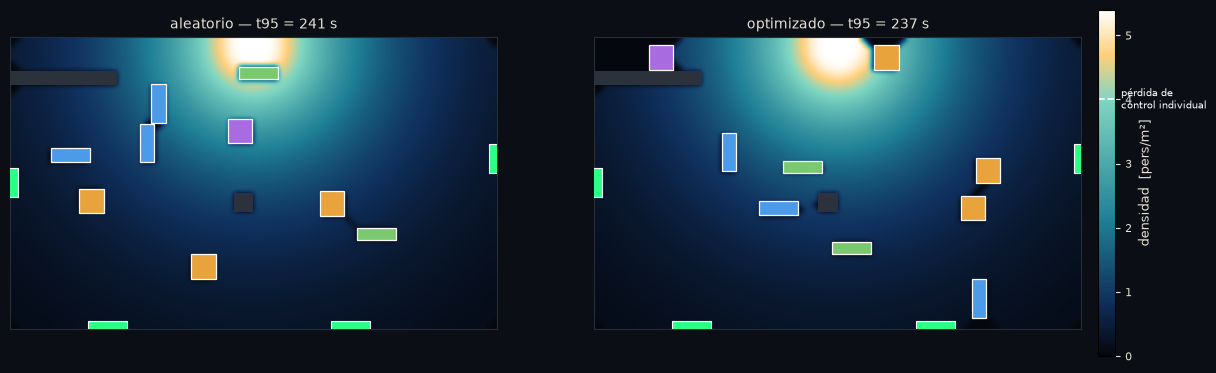

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14.4, 4.5))
for ax, (lay, tit) in zip(axes, [(semillas[0], 'aleatorio'), (res['mejor'], 'optimizado')]):
    ocl, _ = G.zona_ocupable(rec_o, lay)
    Ml = C.distribucion_inicial(rec_o, ocl, AFORO, foco=FOCO, escala=ESCALA)
    V.mapa_densidad(ax, rec_o, Ml / rec_o.area_celda, lay, libre=ocl)
    ax.set_title('%s — t95 = %.0f s' % (tit, O.t_evac(rec_o, lay, AFORO, Ml, dt=0.3)),
                 fontsize=10, color=V.TINTA)
V.barra_densidad(fig, axes)
plt.show()

La animación completa y las curvas se generan con:

```bash
py -3.12 nucleo/comparar.py     # → salidas/evacuacion.gif  y  salidas/curvas.png
```

## 11. Qué sigue

**Antes de tocar NSGA-II:**

1. **Cerrar los `PENDIENTE`.** Seis parámetros no tienen fuente verificada: flujo específico,
   capa límite, ancho libre mínimo, distancia máxima de recorrido, tiempo máximo de desalojo y
   profundidad del área de descarga. Los cuatro últimos son normativos y salen del RCDF+NTC.
2. **Análisis de sensibilidad** de lo marcado `calibrar`: σ del núcleo de densidad, densidad de
   diseño, fracción máxima de área perdida. El criterio no es el error absoluto sino que
   **el orden entre layouts no cambie**.
3. **Segunda función objetivo.** Con una sola no hay nada que barrer. La candidata natural es
   accesibilidad (tiempo medio al servicio más cercano), que es geometría pura a velocidad
   libre y por eso no se traslapa con la evacuación.
4. **Barrido de pesos** sobre la suma ponderada de las dos, w de 0.1 a 0.9. Si los puntos
   trazan un frente con hundimientos → el problema es genuinamente multiobjetivo y NSGA-II está
   justificado. Si trazan una recta o se agolpan en dos extremos → no lo está.

**Advertencia sobre el barrido:** una suma ponderada **solo puede alcanzar la envolvente convexa
del frente**. Si aparecen huecos, no significa que no haya soluciones ahí: significa que el
método no puede verlas. Ese es precisamente el argumento para NSGA-II — y sale de tus propios
datos, no de un argumento teórico prestado.